# Unit 5 Classification model in ML ~ 12 marks

# Classification models vs regression models

# ***Classification***

- **Data:** Divided into predefined, discrete categories

- **Goal:** Assign an input to one of the categories

- **Model output:** A specific category from a set

# ***Regression***

- **Data:** Continuous numerical data with an underlying relationship

- **Goal:** Predict one variable based on others

- **Model output:** A numerical value

  
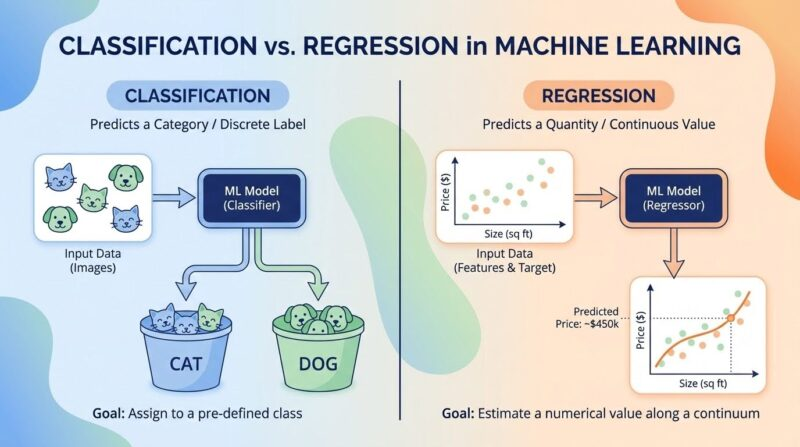


## Decision tree
- a tree like rule based system
- used for classification/regression problems


### Python implementation of job offered dataset

In [1]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier,plot_tree  #plot_tree not in syllabus
import matplotlib.pyplot as plt  #Optional
import seaborn as sns  #Optional

In [4]:
df = pd.read_csv('https://raw.githubusercontent.com/patelmanishv/Sem4Data/refs/heads/main/Datasets/job_offers.csv')
df.head()

,CGPA,Communication,Aptitude,ProgrammingSkill,JobOffered
0,2,1,1,1,1
1,1,1,1,1,1
2,0,0,0,1,0
3,0,1,0,0,0
4,2,1,1,0,1


In [5]:
# Define features and target
x = df.drop(columns=['JobOffered'])  #Feature/independent variable
y = df['JobOffered']  #Target/Dependent variable
print(x.shape)
print(y.shape)

(20, 4)
(20,)


In [6]:
## Create model
dtree = DecisionTreeClassifier(criterion='entropy',
                              max_depth=3)  #max_depth is for accurary. after 3 accuracy will start decreasing

In [7]:
# Fit the model
dtree.fit(x,y)

,criterion,'entropy'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [8]:
# Prediction
y_pred = dtree.predict(x)
print(y_pred)

[1 1 0 0 1 1 0 0 1 1 0 0 1 0 0 0 0 0 0 1]


# Plot the tree (Not in syllabus)


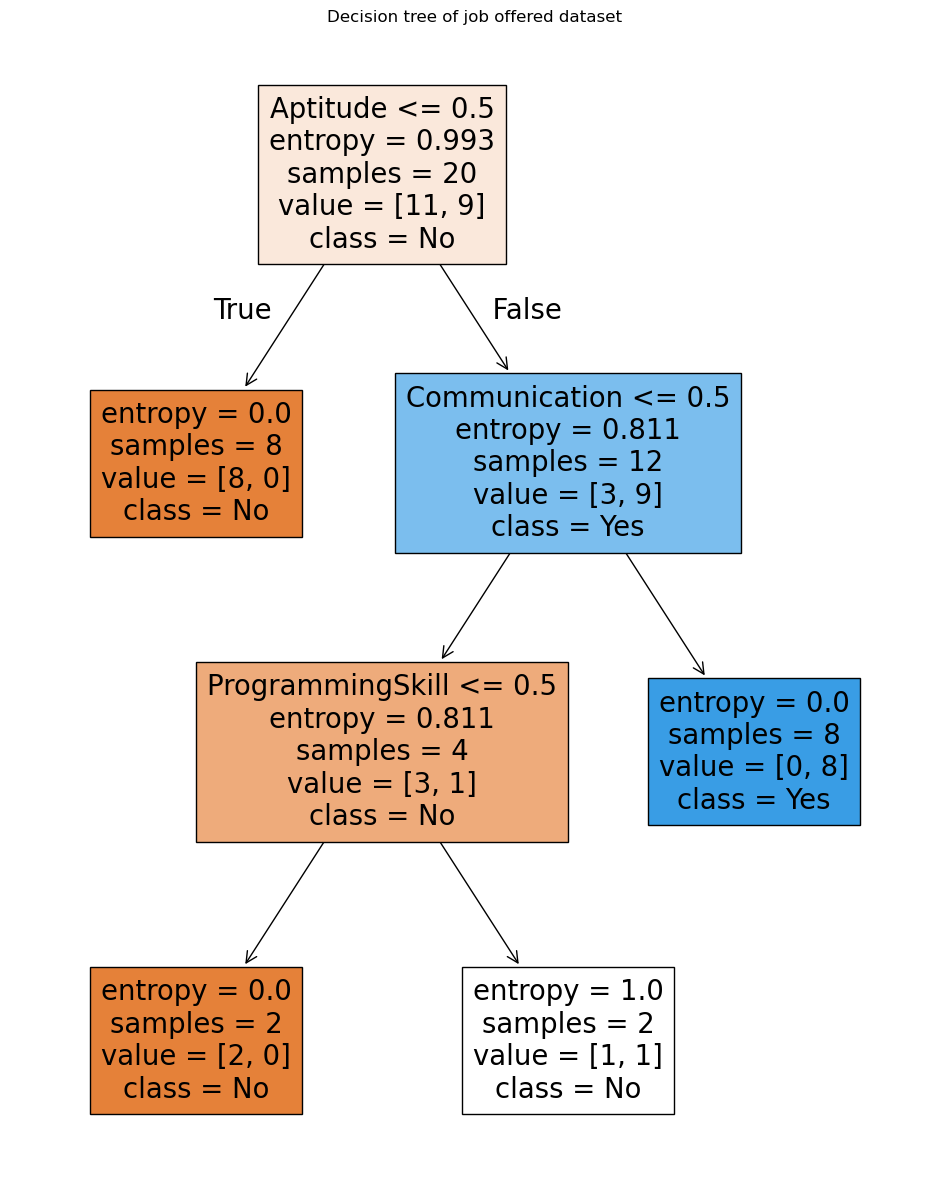

In [9]:
plt.figure(figsize=(12,15))
plot_tree(dtree,filled=True,
         feature_names=['CGPA','Communication','Aptitude','ProgrammingSkill'],
         class_names=['No','Yes'])
plt.title("Decision tree of job offered dataset")
plt.show()

## Evaluation metrics in classification model
- confusion matrix
- accuracy score
- precisoin score
- recall score
- f1 score
- classification report

In [10]:
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score,classification_report

## Confusion matrix

In [11]:
cm = confusion_matrix(y,y_pred)
print("Confusion matrix = \n",cm)

Confusion matrix = 
 [[11  0]
 [ 1  8]]


In [12]:
TN,FP,FN,TP = cm.ravel()
print("True Negatives = ",TN)
print("False Positives = ",FP)
print("Flase Negatives = ",FN)
print("True Positives = ",TP)


True Negatives =  11
False Positives =  0
Flase Negatives =  1
True Positives =  8


# Accuracy Score
- accuracy = (TN + TP)/(TN+FP+FN+TP)

In [18]:
accuracy  = (TN + TP)/(TN+FP+FN+TP)
print(accuracy)
## Alternate way 
print(accuracy_score(y,y_pred))

0.95
0.95


## Precision
- precision = TP / (TP+FP)

In [24]:
precision = TP / (TP+FP)
print(precision)
# Alternate way
print(precision_score(y,y_pred))

1.0
1.0


## Recall
- recall = TP / (TP+FN)

In [25]:
recall = TP / (TP+FN)
print(recall)
# Alternate way
print(recall_score(y,y_pred))

0.8888888888888888
0.8888888888888888


## F1 Score
f1score = 2 * (precision * recall)/(precision + recall)

In [26]:
f1score = 2 * (precision * recall)/(precision + recall)
print(f1score)

# Alternate way
print(f1_score(y,y_pred))

0.9411764705882353
0.9411764705882353


## Classification report


In [27]:
print(classification_report(y,y_pred))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96        11
           1       1.00      0.89      0.94         9

    accuracy                           0.95        20
   macro avg       0.96      0.94      0.95        20
weighted avg       0.95      0.95      0.95        20



## Plotting confusion matrix heatmap

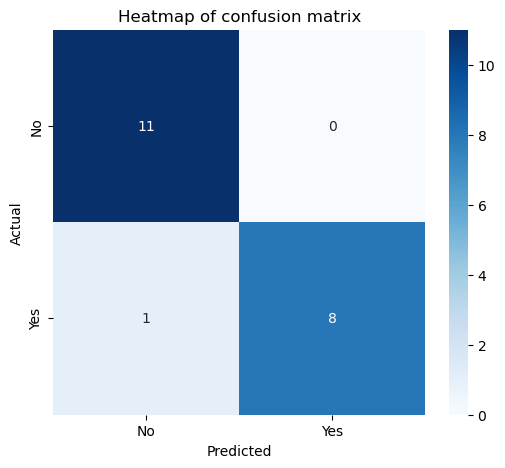

In [29]:
plt.figure(figsize=(6,5))
sns.heatmap(cm,
           annot= True,
           fmt='d',       #format type
           cmap='Blues',
           xticklabels=['No','Yes'],
           yticklabels=['No','Yes'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Heatmap of confusion matrix")
plt.show()

## PB 264
```
Write Python code to train a decision tree classifier with entropy as the criterion using the following steps:
- Initialize a Decision Tree classifier with entropy as the criterion.
- Train the classifier on the training set.
- Make predictions on the test set.
- Calculate and print the confusion matrix for the classifier.

```

## ***Solution***
```python
# Assuming that the libraries and the dataset is imported and split into training and testing
dtree= DecisionTreeClassifier(criterion='entropy')
dtree.fit(x_train,y_train)
y_pred = dtree.predict(x_test)
cm = confusion_matrix(y_test,y_pred)
print(cm)
```
       

## PB 265
```
Write Python code to evaluate the performance of a classification model using the following steps:
- Import the necessary functions from sklearn.metrics.
- Calculate and print the classification report for the true labels and predicted labels.
- Calculate and print the accuracy score of the classifier.
```
## ***Solution***
```python
from sklearn.metrics import classification_report,accuracy_score
print(classification_report(y,y_pred))
print(accuracy_score(y,y_pred))
```


## Manual calculation of evaluation metrics (important for mcqs)

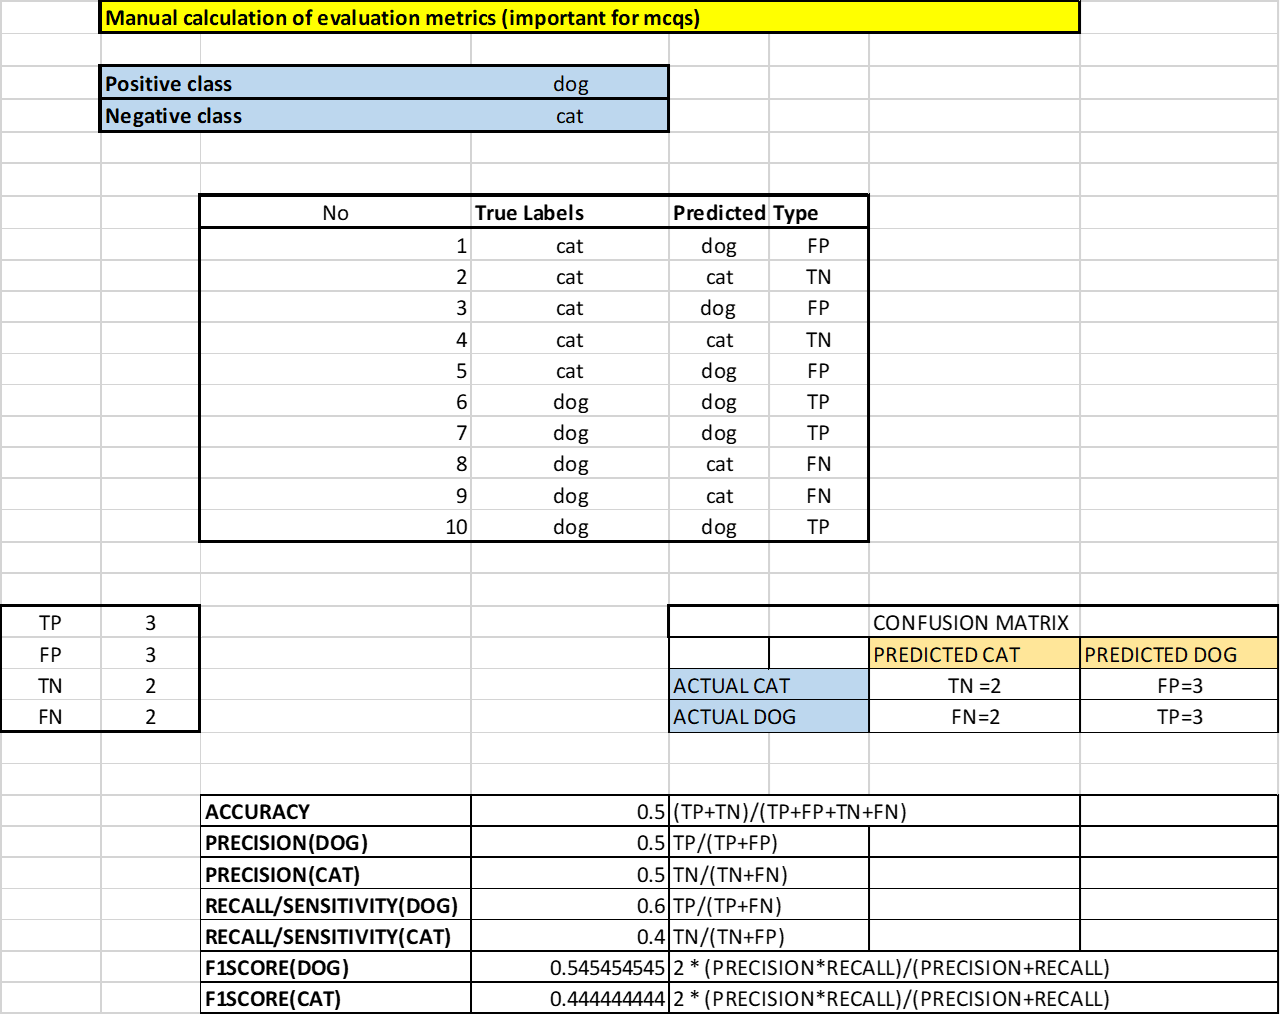

## PB 271
```
The task involves building a Decision Tree classifier to predict whether to play tennis based on weather conditions. The dataset
used for this task is the PlayTennis dataset, which contains information about various weather attributes such as outlook,
temperature, humidity, and wind, along with the corresponding decision to play tennis or not. Use PlayTennis.csv for dataset.
```

In [2]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report

In [3]:
df = pd.read_csv('PlayTennis.csv')
df.head()

,outlook,temp,humidity,windy,play
0,sunny,hot,high,False,no
1,sunny,hot,high,True,no
2,overcast,hot,high,False,yes
3,rainy,mild,high,False,yes
4,rainy,cool,normal,False,yes


In [4]:
## Convert categorical data to numerical
data = pd.get_dummies(df,columns=['outlook','temp','humidity','windy'])
data.head()

,play,outlook_overcast,outlook_rainy,outlook_sunny,temp_cool,temp_hot,temp_mild,humidity_high,humidity_normal,windy_False,windy_True
0,no,False,False,True,False,True,False,True,False,True,False
1,no,False,False,True,False,True,False,True,False,False,True
2,yes,True,False,False,False,True,False,True,False,True,False
3,yes,False,True,False,False,False,True,True,False,True,False
4,yes,False,True,False,True,False,False,False,True,True,False


In [5]:
## create features and target
x = data.drop(columns=['play'])
y = data['play']
print(x.shape)
print(y.shape)

(14, 10)
(14,)


In [6]:
## Split data
x_train,x_test,y_train,y_test = train_test_split(
    x,y,test_size=0.2,random_state=42
)

In [7]:
## Create model
dtree = DecisionTreeClassifier(criterion='entropy',max_depth=3)

In [8]:
dtree.fit(x_train,y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [9]:
y_pred = dtree.predict(x_test)
print(y_pred)

['yes' 'yes' 'no']


In [10]:
## Confusion matrix
cm = confusion_matrix(y_test,y_pred)
print("Confusion matrix: \n",cm)

Confusion matrix: 
 [[1 0]
 [0 2]]


In [11]:
## Classification report
cr = classification_report(y_test,y_pred)
print("Classification report : \n",cr)

Classification report : 
               precision    recall  f1-score   support

          no       1.00      1.00      1.00         1
         yes       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



In [12]:
## prediction for new data
new_data = pd.DataFrame({
    'outlook' : ['rainy'],
    'temp' : ['mild'],
    'humidity' : ['normal'],
    'windy' : ['FALSE']
})
new_data = pd.get_dummies(new_data)
missingcols = set(x.columns) - set(new_data.columns)
print(missingcols)

{'windy_True', 'outlook_sunny', 'humidity_high', 'temp_hot', 'windy_False', 'temp_cool', 'outlook_overcast'}


In [13]:
for col in missingcols:
    new_data[col] = 0
new_data = new_data[x.columns]
new_data

,outlook_overcast,outlook_rainy,outlook_sunny,temp_cool,temp_hot,temp_mild,humidity_high,humidity_normal,windy_False,windy_True
0,0,True,0,0,0,True,0,True,0,0


In [14]:
newprediction = dtree.predict(new_data)
print(newprediction)

['yes']


### KNN ALGO
**STEPS**
1. Fix parameter k(nearest neighbour)
2. Calculate distance between query and all training samples
3. sorth the distance and determine nearest neighbors based on kth min distance
4. gather category of nearest neighbors.
5. Use majority of category to predict the query value.

						
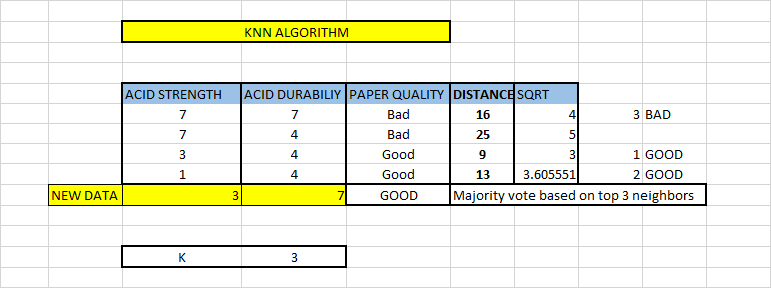

### Python implementation


In [24]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

x = np.array([[7,7],[7,4],[3,4],[1,4]])
y = np.array(['Bad','Bad','Good','Good'])
print(x.shape)
print(y.shape)

knn = KNeighborsClassifier(n_neighbors=3)                                                                                         

knn.fit(x,y)

print(knn.predict([[3,7]]))

(4, 2)
(4,)
['Good']


## TEMPLATE PROGRAM FOR THE KNN

In [46]:
# Import Libraries
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection  import train_test_split
from sklearn.datasets import load_wine
from sklearn.metrics import accuracy_score,confusion_matrix

# Import datasets
wine = load_wine()

# Define features and target
x = wine.data
y = wine.target
print(x.shape)
print(y.shape)

# split the data
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=42)

# create and fit model
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train,y_train)

# Prediction
y_pred = knn.predict(x_test)
print(y_pred)

# Confusion Matrix and accuracy score
print("Confusion matrix:\n",confusion_matrix(y_test,y_pred))
print("Accuracy score:",accuracy_score(y_test,y_pred))

(178, 13)
(178,)
[2 0 2 0 1 0 1 2 0 0 2 2 0 1 0 1 1 1 0 1 0 1 2 2 1 1 1 2 1 0 0 1 2 0 0 0 2
 2 2 1 0 1 1 2 2]
COnfusion matrix:
 [[13  0  2]
 [ 1 13  4]
 [ 1  3  8]]
Accuracy score: 0.7555555555555555


### Implement using decision tree

In [47]:
# Import Libraries
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection  import train_test_split
from sklearn.datasets import load_wine
from sklearn.metrics import accuracy_score,confusion_matrix

# Import datasets
wine = load_wine()

# Define features and target
x = wine.data
y = wine.target
print(x.shape)
print(y.shape)

# split the data
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=42)

# create and fit model
dtree = DecisionTreeClassifier(criterion='entropy',max_depth=3)
dtree.fit(x_train,y_train)

# Prediction
y_pred = dtree.predict(x_test)
print(y_pred)

# Confusion Matrix and accuracy score
print("Confusion matrix:\n",confusion_matrix(y_test,y_pred))
print("Accuracy score:",accuracy_score(y_test,y_pred))

(178, 13)
(178,)
[0 0 1 0 1 0 1 2 1 0 0 1 0 2 0 1 1 1 0 1 0 1 1 2 2 2 1 1 1 0 0 1 2 0 0 0 2
 2 1 2 0 1 1 1 1]
Confusion matrix:
 [[15  0  0]
 [ 0 17  1]
 [ 1  3  8]]
Accuracy score: 0.8888888888888888


### WAP TO PREDICT ON DIABETES DATASET BASED ON DECISION TREE AND KNN
- train size 75%
- random state 42
- max depth 3
- n neighbours 3
- criterian = entropy

In [72]:
# Using Decision tree
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix

df = pd.read_csv("diabetes.csv")
df.head(2)

x = df.drop(columns=['Outcome'])
y = df['Outcome']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=42)

dtree = DecisionTreeClassifier(criterion='entropy',max_depth=3)

dtree.fit(x_train,y_train)

y_pred = dtree.predict(x_test)
print(y_pred)

print("Confusion matrix:\n",confusion_matrix(y_test,y_pred))
print("Accuracy score:",accuracy_score(y_test,y_pred))

[0 0 0 0 0 0 0 0 1 1 0 1 1 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 1 1 1 1 0 1 1
 0 0 0 0 0 0 0 0 1 0 0 0 1 0 1 0 0 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 0 0
 0 0 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 0 1 1 0 0 1 0 0 0
 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 1 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0 0
 0 1 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 1 0 1 1 0 1 0 0 0 1 0 0 0 0 0 1 1 0 1 0
 0 0 0 1 0 0 0]
Confusion matrix:
 [[105  18]
 [ 36  33]]
Accuracy score: 0.71875


In [71]:
# Using KNN
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix

df = pd.read_csv("diabetes.csv")
df.head(2)

x = df.drop(columns=['Outcome'])
y = df['Outcome']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=42)

knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(x_train,y_train)

y_pred = knn.predict(x_test)
print(y_pred)

print("Confusion matrix:\n",confusion_matrix(y_test,y_pred))
print("Accuracy score:",accuracy_score(y_test,y_pred))

[0 1 0 1 1 1 0 0 1 1 0 1 0 0 0 1 0 0 1 1 1 0 1 0 1 1 0 0 0 0 1 0 1 1 0 1 1
 0 0 1 0 1 1 1 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 1 1 0 0 0
 0 1 0 0 0 0 1 0 0 1 0 1 1 0 0 0 0 0 0 0 1 1 1 0 1 0 1 0 0 0 1 1 0 1 0 1 0
 1 0 1 1 1 1 0 0 0 0 0 1 0 1 1 0 1 1 1 1 0 1 1 1 1 0 1 1 0 0 0 0 1 0 0 0 0
 1 1 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 1 0 1 1 0 1 0 0 1 1 0 0 0 1 0 0 0 1 1 0
 0 0 0 1 0 0 1]
Confusion matrix:
 [[83 40]
 [29 40]]
Accuracy score: 0.640625


### Support vector machine
- lil bro is used for classification models based on concept of hyperplans


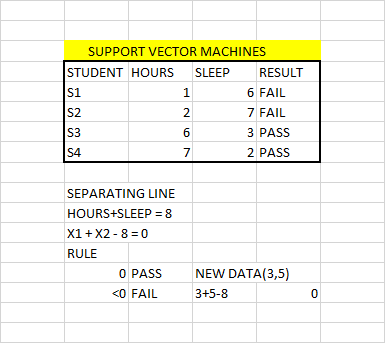

In [75]:
from sklearn.svm import SVC

In [76]:
x = np.array([[1,6],[2,7],[6,3],[7,2]])
y = np.array([0,0,1,1])

In [77]:
model = SVC(kernel='linear')
model.fit(x,y)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [81]:
model.predict([[5,3]])

array([1])